In [1]:
#input files:
mtx_file = "Analysis/10X_LN/01_raw_data/gex_matrix/filtered_feature_bc_matrix/matrix.mtx.gz"
features_file = "Analysis/10X_LN/01_raw_data/gex_matrix/filtered_feature_bc_matrix/features.tsv.gz"
barcodes_file = "Analysis/10X_LN/01_raw_data/gex_matrix/filtered_feature_bc_matrix/barcodes.tsv.gz"

#output files:
idents_out_path = "Analysis/10X_LN/gex_clustering/LN_RNA_idents.RDS"
lib_size_out_path = "Analysis/10X_LN/gex_clustering/LN_RNA_lib_size.RDS"
rna_pca_out_path = "Analysis/10X_LN/gex_clustering/LN_RNA_pca.RDS"

In [2]:
library(Seurat)

Attaching SeuratObject
‘SeuratObject’ was built under R 4.3.1 but the current version is
4.3.3; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


In [3]:
setwd(here::here()) # set working directory to project root
getwd()

[1] "/sci/labs/yotamd/lab_share/avishai.wizel/Projects/eRNA"

In [4]:
LN.data <- Read10X(data.dir = dirname(mtx_file))


10X data contains more than one type and is being returned as a list containing matrices of each type.


In [5]:
names(LN.data)

[1] "Gene Expression" "Peaks"          

# 10X LN clustering using Seurat
This notebook adds a minimal Seurat workflow: create Seurat object from Read10X output (variable `LN` in earlier cell), QC/filtering, normalization, PCA, clustering, UMAP, and marker finding. Adjust filtering thresholds and clustering resolution to your dataset.

In [6]:
# Create Seurat object and perform basic QC
library(dplyr)

# `LN` was created earlier with Read10X
LN <- CreateSeuratObject(counts = LN.data[[1]], project = "LN14K", min.cells = 3, min.features = 200)


Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



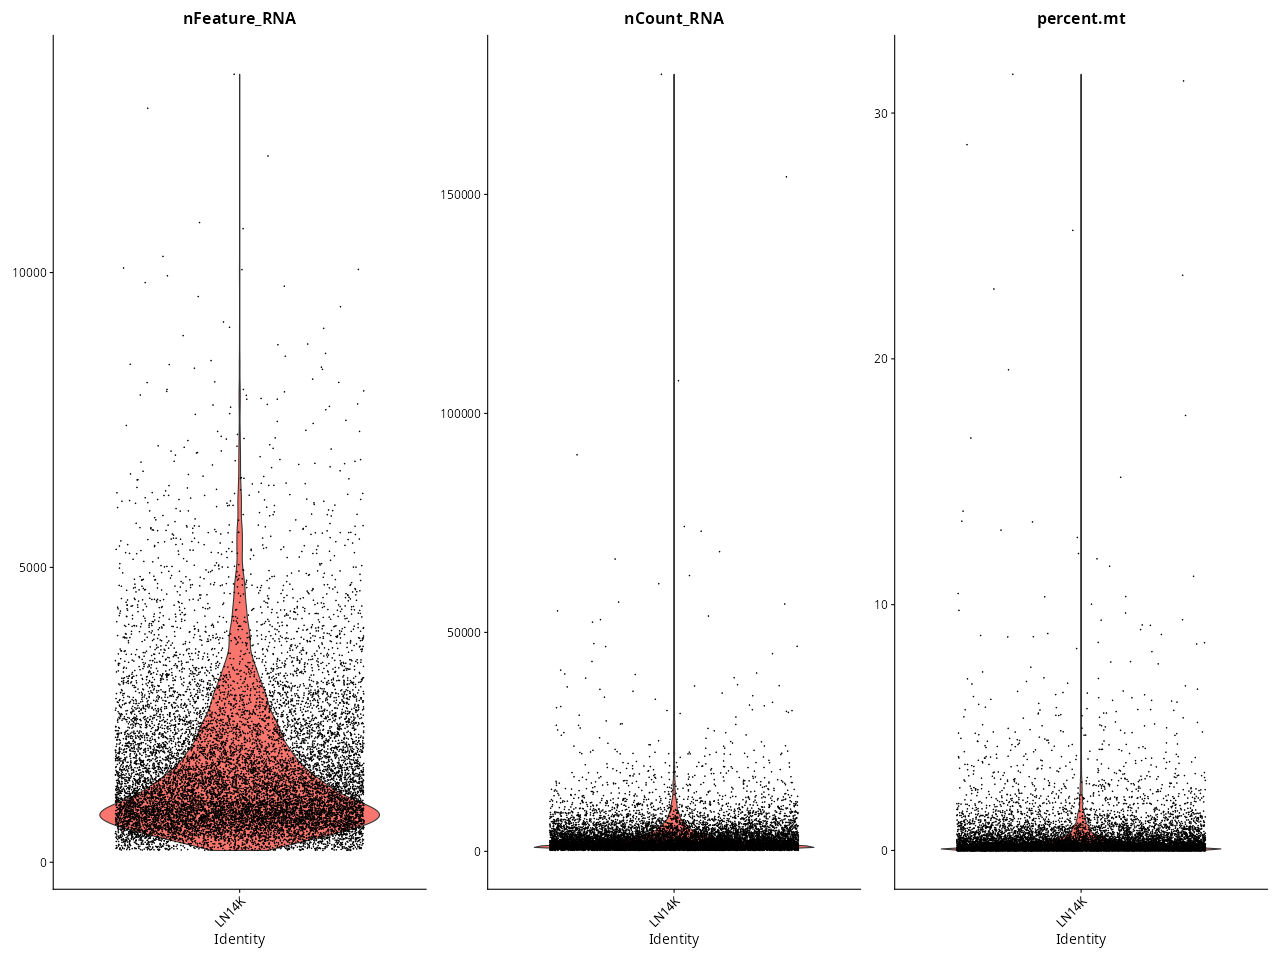

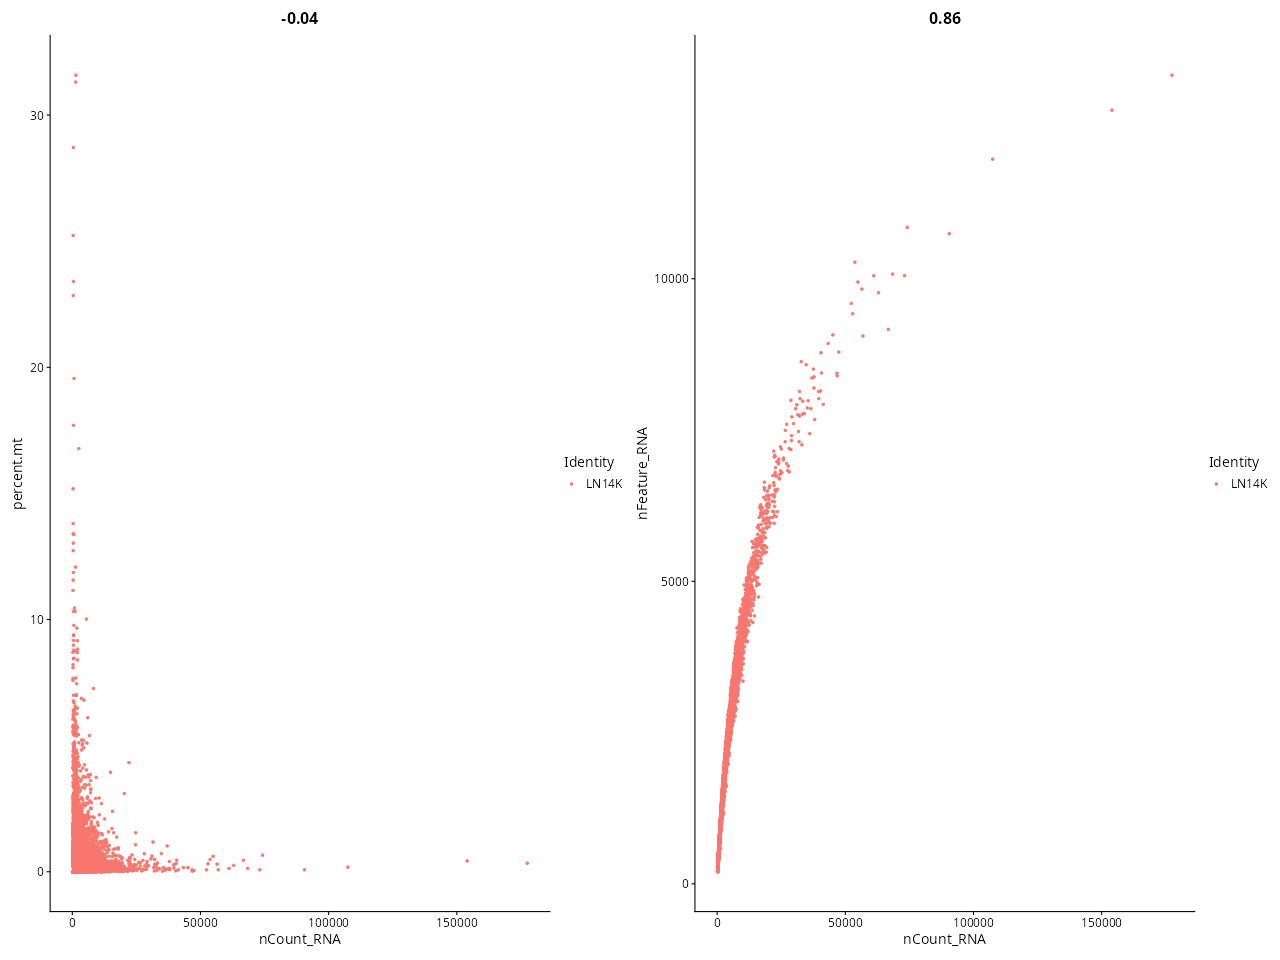

In [7]:

options(ark.plot.width = 3)
options(ark.plot.height = 7)

# percent mitochondrial genes (human: MT- prefix)
LN[["percent.mt"]] <- PercentageFeatureSet(LN, pattern = "^MT-")

# QC plots
VlnPlot(LN, features = c("nFeature_RNA", "nCount_RNA", "percent.mt"), ncol = 3)
plot1 <- FeatureScatter(LN, feature1 = "nCount_RNA", feature2 = "percent.mt")
plot2 <- FeatureScatter(LN, feature1 = "nCount_RNA", feature2 = "nFeature_RNA")
plot1 + plot2



In [8]:
# Filter cells - adjust thresholds as needed
LN <- subset(LN, subset = nFeature_RNA > 200 & nFeature_RNA < 3000 & percent.mt < 25)

LN

An object of class Seurat 
27471 features across 12574 samples within 1 assay 
Active assay: RNA (27471 features, 0 variable features)

In [9]:
lib_size_gex <- colSums(GetAssayData(LN, assay = "RNA", slot = "counts"))
names(lib_size_gex) <- colnames(LN)

Performing log-normalization
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Calculating gene variances
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Calculating feature variances of standardized and clipped values
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
Warning message:
In scale_x_log10() :
  log-10 transformation introduced infinite values.


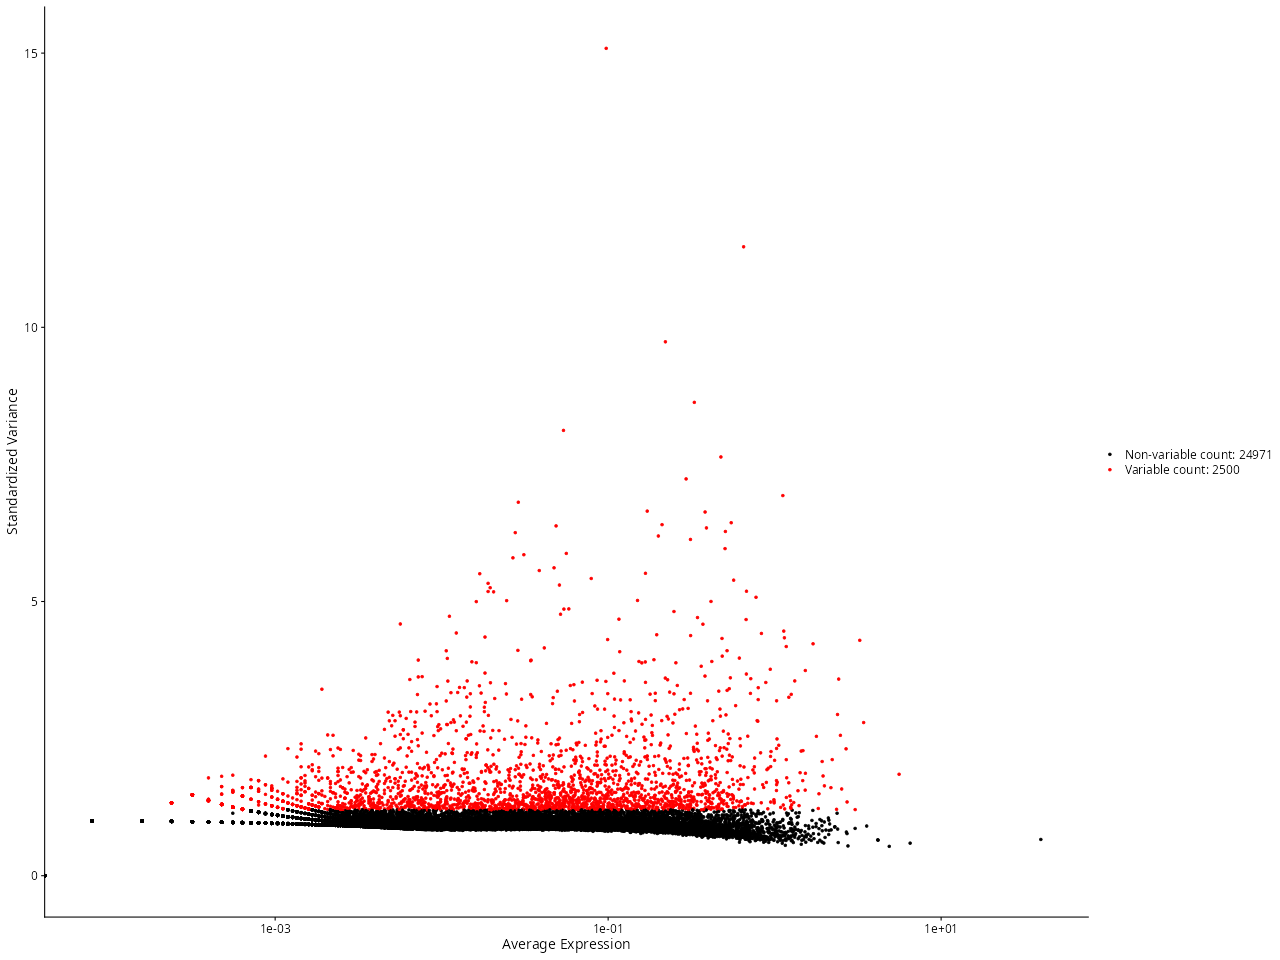

In [10]:
# Normalization, dimensionality reduction and clustering

# Normalize and identify variable features
LN <- NormalizeData(LN, normalization.method = "LogNormalize", scale.factor = 1e6)
LN <- FindVariableFeatures(LN, selection.method = "vst", nfeatures = 2500)

# Visualize variable features
top10 <- head(VariableFeatures(LN), 10)
VariableFeaturePlot(LN)




Centering and scaling data matrix


  |======================================================================| 100%


PC_ 1 
Positive:  UBE2E2, LYN, RBM47, AL162414.1, DMXL2, SLC8A1, LRMDA, KCNMA1, FMNL2, DOCK4 
	   AC083837.1, MARCH1, LRRK2, SYK, DAPK1, WDFY3, PLXDC2, KYNU, SLC1A3, CYBB 
	   CCDC88A, MCTP1, RNF144B, MITF, TFEC, HCK, TCF4, TNFAIP2, MYOF, RTN1 
Negative:  INPP4B, LINC01934, PDE3B, PRF1, AGAP1, ANK3, GNLY, CADM1, CBLB, LAG3 
	   AF165147.1, DTHD1, CCL5, NKG7, ST8SIA1, GZMB, PDE4D, AC139720.1, TSPAN5, TRERF1 
	   PAM, AL133405.2, TRBC1, ST6GALNAC3, MEAK7, TOX, RUNX2, FAAH2, NELL2, CCL4 
PC_ 2 
Positive:  AC090125.1, LINC01320, GPM6A, FCRL5, IGF2BP3, PAX5, NIBAN3, RASGRF1, ARHGAP24, RHEX 
	   FCRL2, AL592429.2, RALGPS2, KHDRBS2, BLK, KIAA1217, AC020584.1, LINC02055, EBF1, DGKG 
	   MS4A1, CD22, NRCAM, DISC1FP1, BLNK, CD83, AFF3, RASGRP3, RUBCNL, OSBPL10 
Negative:  SLC8A1, AL162414.1, LRMDA, KCNMA1, DOCK4, PLXDC2, DAPK1, DPYD, WDFY3, FMNL2 
	   TNFAIP2, MYOF, SLC1A3, MITF, RTN1, ANKRD22, RASSF4, TFEC, FAM20A, ABCA1 
	   RGL1, FRMD4B, FMN1, CMKLR1, IRAK3, EPB41L3, GNAQ, ARHGEF10L, CD163, C

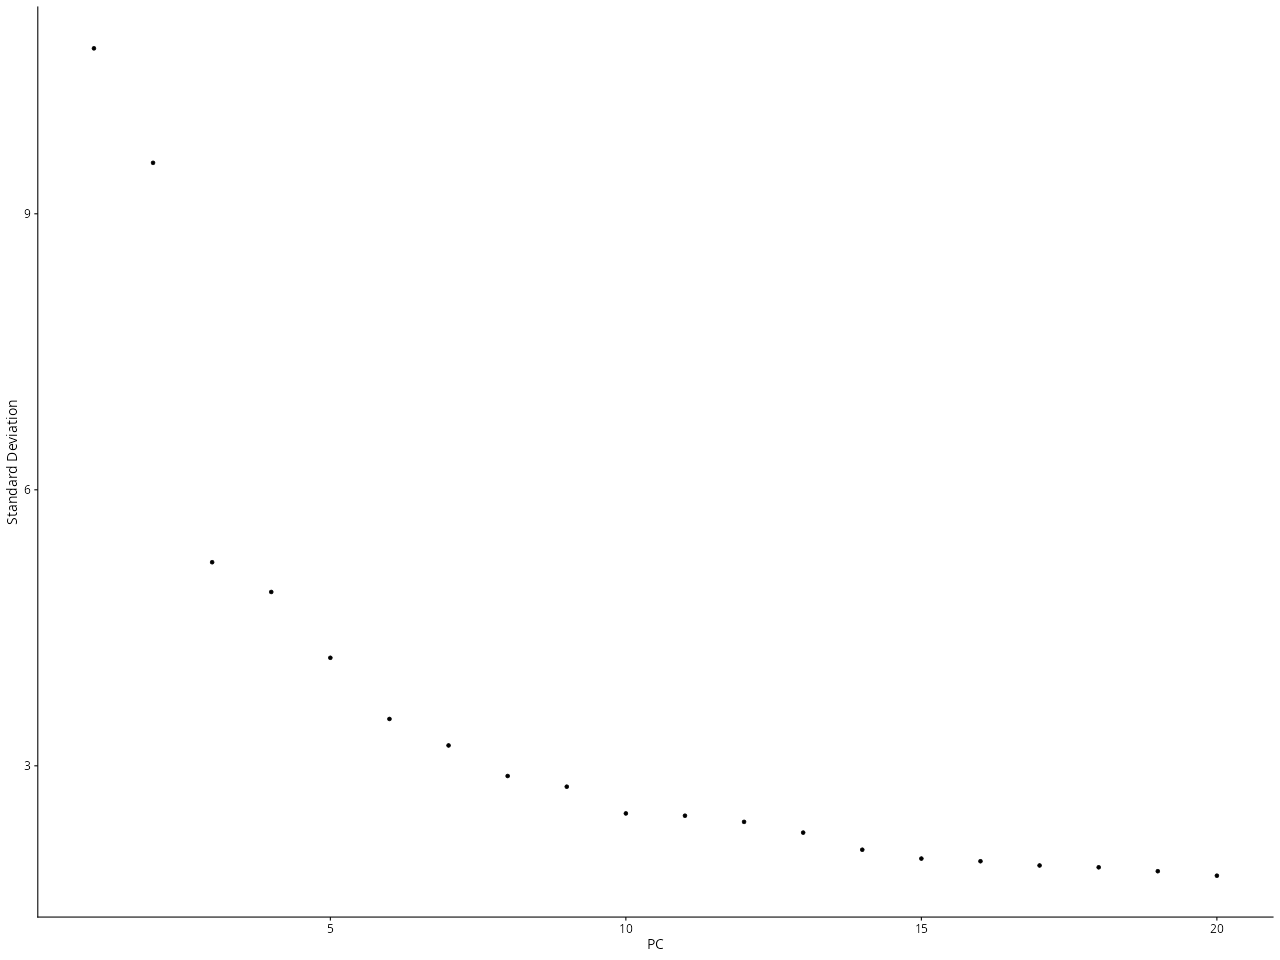

In [11]:
# Scale, PCA
LN <- ScaleData(LN, features = VariableFeatures(LN))
LN <- RunPCA(LN, features = VariableFeatures(object = LN))
ElbowPlot(LN)



In [18]:
# Neighborhood graph, clustering and UMAP
LN <- FindNeighbors(LN, dims = 1:10)
LN <- FindClusters(LN, resolution = 0.3)
LN <- RunUMAP(LN, dims = 1:10)



Computing nearest neighbor graph
Computing SNN
Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12574
Number of edges: 394574

Running Louvain algorithm...


0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|


Maximum modularity in 10 random starts: 0.9138
Number of communities: 8
Elapsed time: 1 seconds
15:39:38 UMAP embedding parameters a = 0.9922 b = 1.112
15:39:38 Read 12574 rows and found 10 numeric columns
15:39:38 Using Annoy for neighbor search, n_neighbors = 30
15:39:38 Building Annoy index with metric = cosine, n_trees = 50
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|
15:39:40 Writing NN index file to temp file /tmp/RtmpoPPfkO/file12abe82701a2ff
15:39:40 Searching Annoy index using 1 thread, search_k = 3000
15:39:45 Annoy recall = 100%
15:39:45 Commencing smooth kNN distance calibration using 1 thread with target n_neighbors = 30
15:39:46 Initializing from normalized Laplacian + noise (using irlba)
15:39:47 Commencing optimization for 200 epochs, with 498856 positive edges
15:39:47 Using rng type: pcg


Using method 'umap'
0%   10   20   30   40   50   60   70   80   90   100%
[----|----|----|----|----|----|----|----|----|----|
**************************************************|


15:39:53 Optimization finished


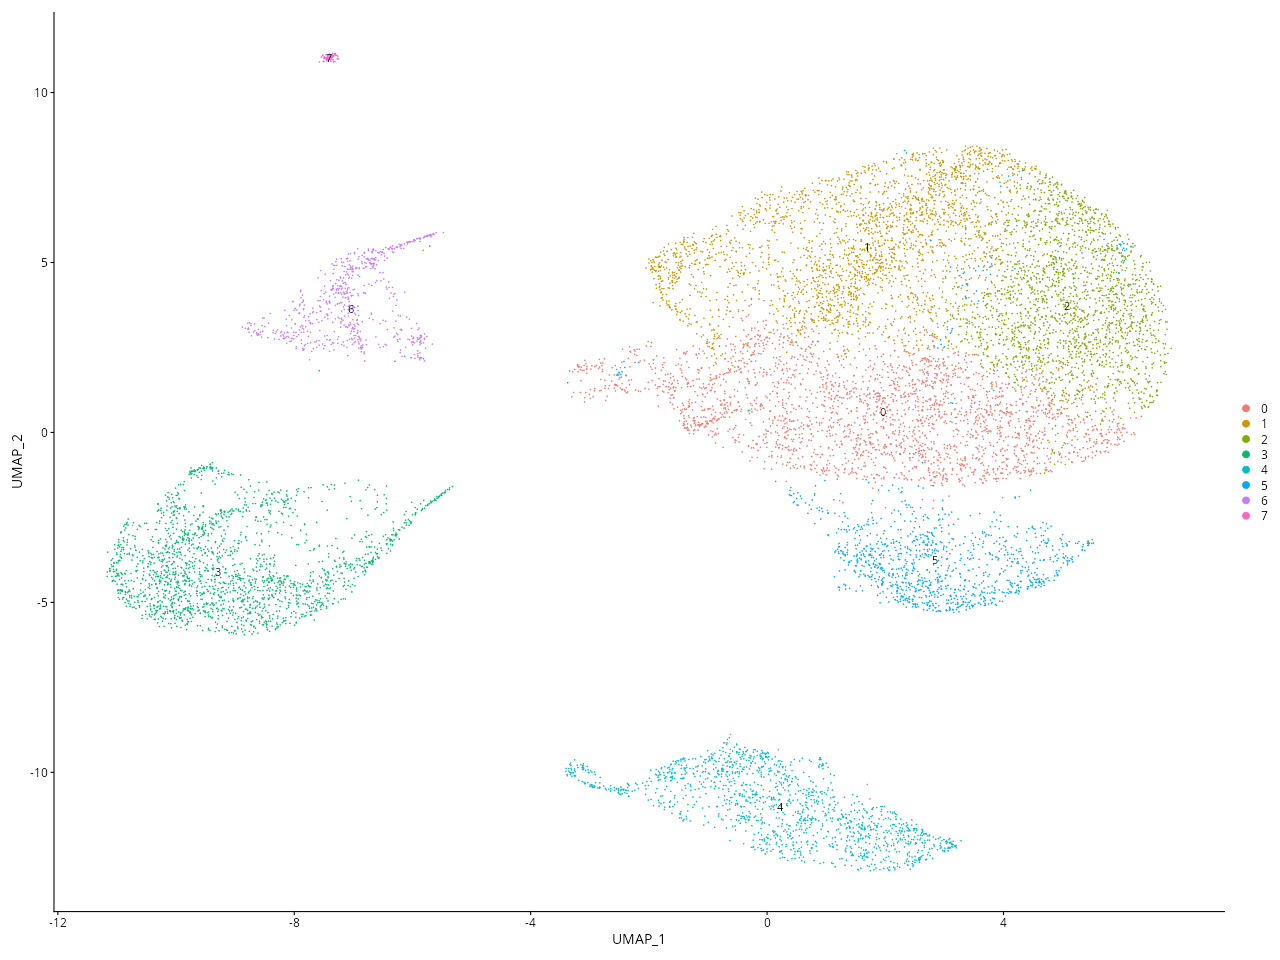

In [19]:
# Plot UMAP
DimPlot(LN, reduction = "umap", label = TRUE)

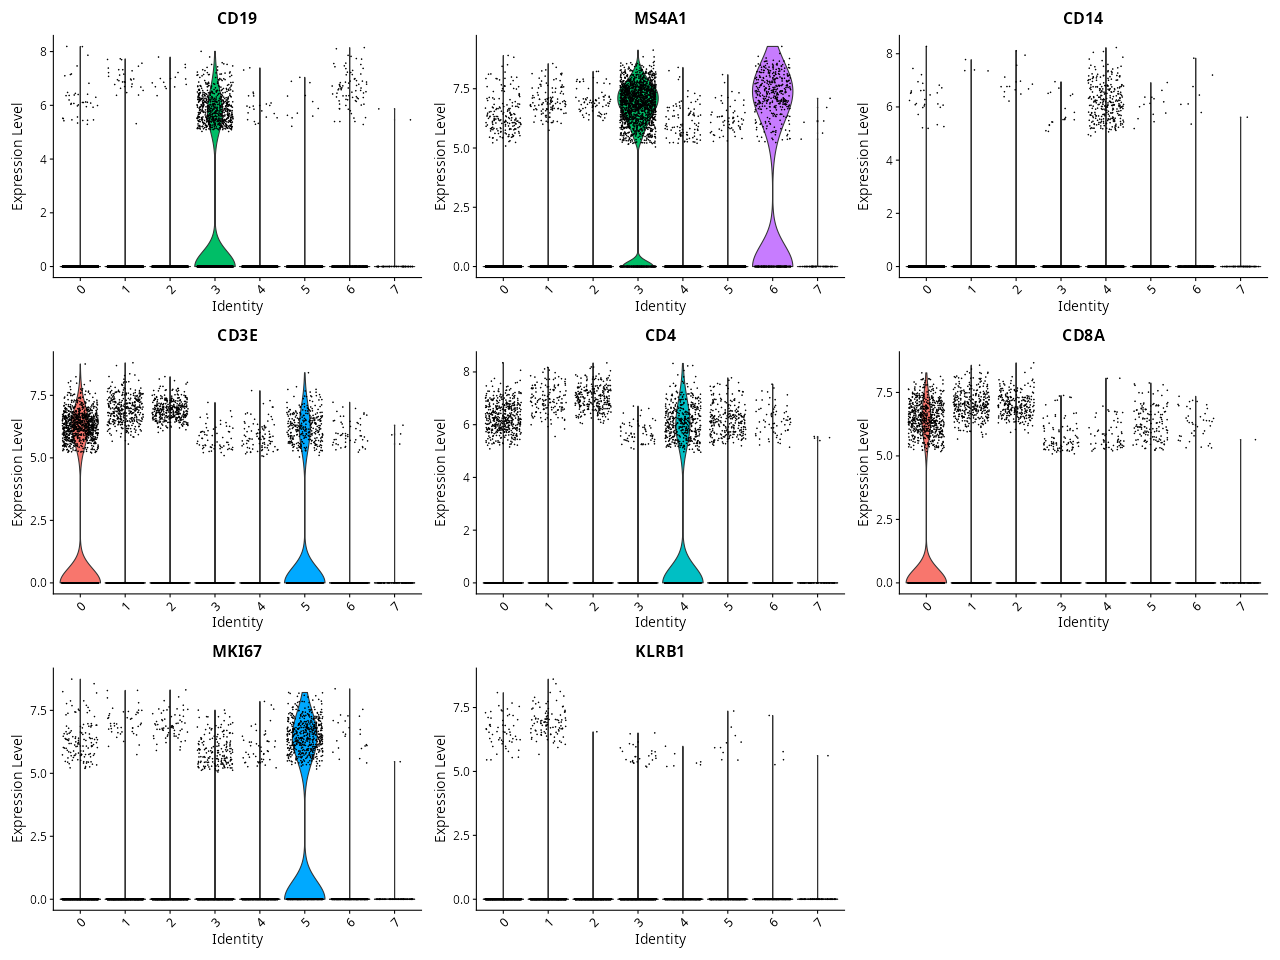

In [20]:
options(repr.plot.width = 3, repr.plot.height = 10) 

VlnPlot(LN, features = c("CD19","MS4A1","CD14","CD3E", "CD4","CD8A","MKI67","KLRB1"))


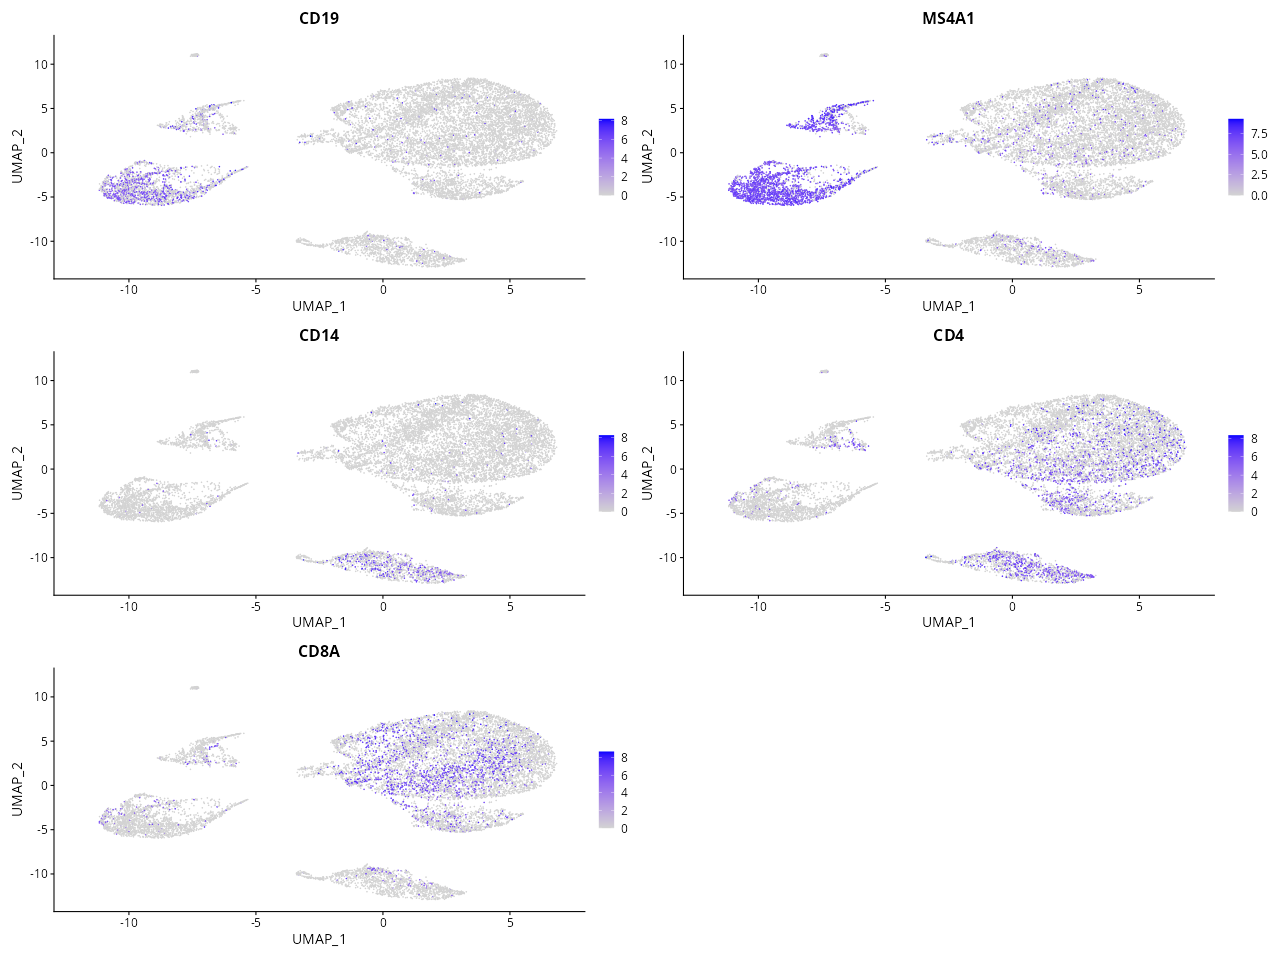

In [21]:
options(repr.plot.width = 12, repr.plot.height = 13) 
FeaturePlot(LN, features = c("CD19","MS4A1","CD14","CD4","CD8A"))

In [22]:
all_markers <- FindAllMarkers(LN, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.25,densify = T)

Calculating cluster 0
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=09s   84% ~02s          
Calculating cluster 1
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=08s   |++++++++++++++++                                  | 30% ~05s          
Calculating cluster 2
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=09s  
Calculating cluster 3
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=26s  
Calculating cluster 4
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=16s  
Calculating cluster 5
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=14s   51% ~07s          
Calculating cluster 6
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=08s  
Calculating cluster 7
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=19s  


In [24]:
all_markers %>% group_by(cluster) %>% top_n(n = 10, wt = avg_log2FC) %>% select(cluster, gene) %>% filter (cluster %in% c( "4", "7"))

# A tibble: 20 × 2
# Groups:   cluster [2]
   cluster gene      
   <fct>   <chr>     
 1 4       AL162414.1
 2 4       KCNMA1    
 3 4       MITF      
 4 4       SLC1A3    
 5 4       RTN1      
 6 4       SLC8A1    
 7 4       PLXDC2    
 8 4       EPB41L3   
 9 4       MYOF      
10 4       DAPK1     
11 7       TFPI      
12 7       LINC02147 
13 7       FBXL7     
14 7       NFIB      
15 7       SGIP1     
16 7       PROX1     
17 7       SNCAIP    
18 7       EGFL7     
19 7       RHOJ      
20 7       ERG       

In [ ]:
LN = SetIdent(LN,value = "RNA_snn_res.0.5")

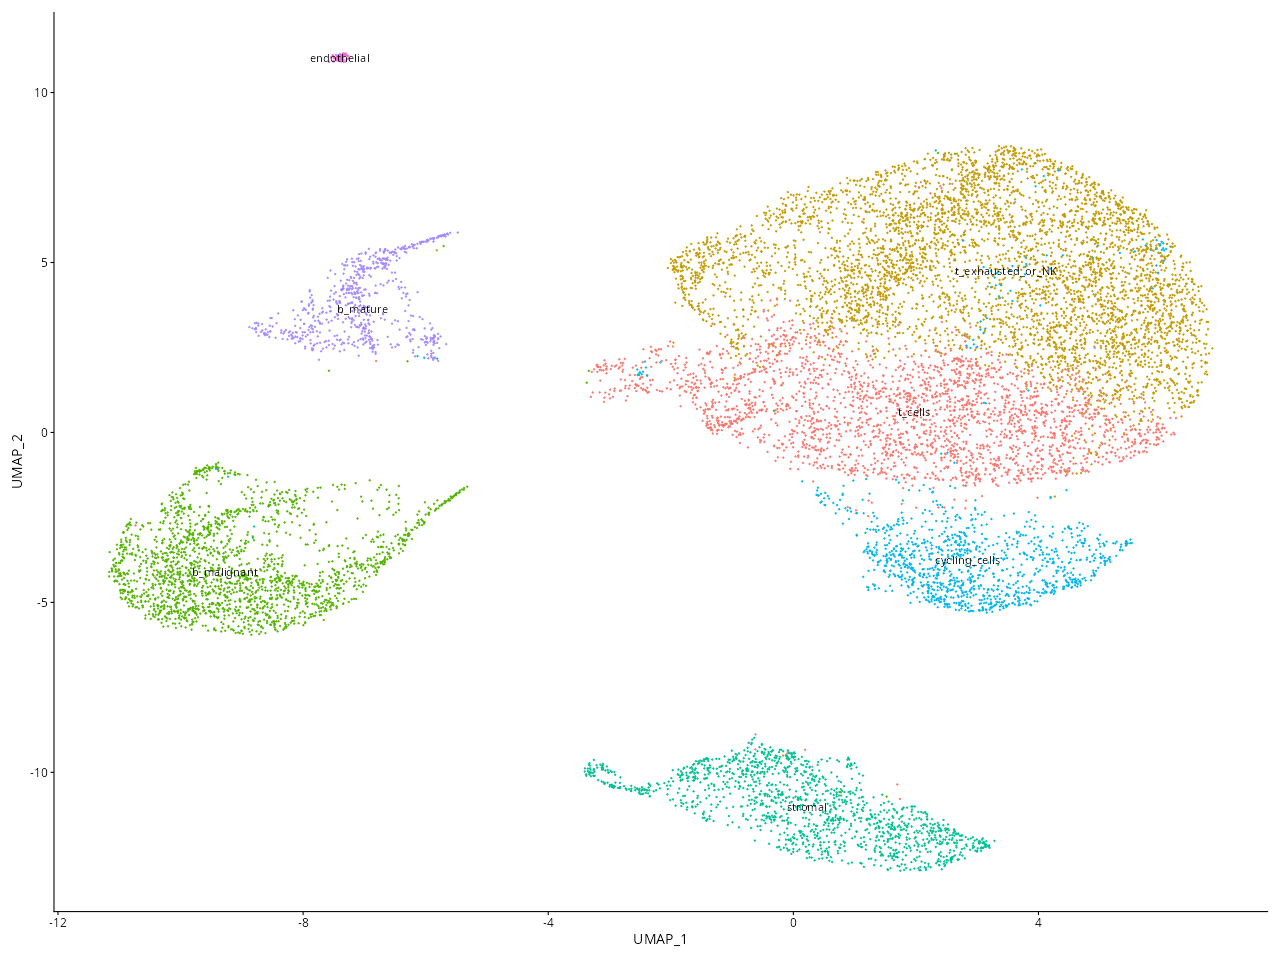

In [29]:
# set clusters based on marker genes
t_cells = c(0)
t_exhausted_or_NK = c(1,2)
b_mature = c(6)
b_malignant = c(3)
cycling_cells = c(5)
stromal = c(4)
endothelial = c(7)
all_values <- c(t_cells, t_exhausted_or_NK, b_mature, b_malignant, cycling_cells, stromal, endothelial)
all_names = c(rep("t_cells", length(t_cells)),
                rep("t_exhausted_or_NK", length(t_exhausted_or_NK)),
                rep("b_mature", length(b_mature)),
                rep("b_malignant", length(b_malignant)),
                rep("cycling_cells", length(cycling_cells)),
                rep("stromal", length(stromal)),
                rep("endothelial", length(endothelial))
                )

names(all_values) <- all_names
#order all_values by value
all_values = all_values[order(all_values)]
new.cluster.ids = names(all_values) 
names(new.cluster.ids) <- levels(LN)

LN <- RenameIdents(LN, new.cluster.ids)
DimPlot(LN, reduction = "umap", label = TRUE, pt.size = 0.5) + NoLegend()



In [ ]:
if (!interactive()){ 
saveRDS(object = as.data.frame(LN@active.ident),file = idents_out_path)
saveRDS(object = lib_size_gex,file = lib_size_out_path)
saveRDS(object = Embeddings(LN, reduction = "pca"),file = rna_pca_out_path)
}


In [ ]:
dim(Embeddings(LN, reduction = "pca"))

                            PC_1          PC_2          PC_3          PC_4          PC_5          PC_6
AAACAGCCAATCCCTT-1  -9.375915813 -2.7616290265 -2.912445e-01  0.8277979945 -2.530844e-01 -5.000611e+00
AAACAGCCAATGCGCT-1  -8.495196842 -1.1733681883  3.546127e+00  2.2468577633 -4.038549e-02  4.023464e-01
AAACAGCCACACTAAT-1 -10.432592265 -2.4872021074  3.123852e+00 -0.0454653684 -3.735057e-01  3.156265e+00
AAACAGCCACCAACCG-1  -8.466728858 -2.0369530234  2.860766e+00  1.5491056294 -7.590767e-01  1.773311e+00
AAACAGCCAGGATAAC-1  -9.843114334 -1.5968422183  4.409045e+00  0.6998321988 -3.662683e-01  1.623495e+00
AAACAGCCAGTTTACG-1  -8.195469706 -2.4754957221  3.268033e+00  0.9344949695 -4.246416e-01 -5.877526e+00
AAACATGCAAGGTCCT-1 -10.076434805 -2.6955079926  4.339763e+00  1.1996108906 -3.590282e-01  4.565373e+00
AAACATGCACCGGCTA-1  -6.188755030 -4.6186289294 -2.075224e+01 -3.2899410693  2.148816e+00  5.128696e+00
AAACATGCACTTGTTC-1  -9.569428236 -1.6239493975  4.230662e+00  0.637449635